# Layer 0: A single training cell

This repo builds the compute-optimal scaling-law pipeline **in layers**, each notebook
wrapping the previous one:

| notebook | layer | what it adds |
|---|---|---|
| **00** (this one) | a single cell | train one model, get one loss |
| **01** | tune one cell | the best learning rate for that cell |
| **02** | the HP law | how the best LR scales, $\eta^\star(w,T)$ |
| **03** | the full sweep | the $(N,D)$ grid + the compute-optimal frontier, three ways |
| **04** | double descent | a different, repeated-data regime |

The atom everything is built from is a **cell**: one training run of a model of size $N$ on
$D$ examples at a learning rate $\eta$, returning a final validation loss.

## The synthetic problem: a Gaussian teacher–student

Inputs are standard Gaussian, $x\sim\mathcal N(0,I_d)$. The target comes from a **fixed,
frozen network**, the *teacher*, plus label noise:

$$y = f_\text{teacher}(x) + \sigma\,\varepsilon,\qquad \varepsilon\sim\mathcal N(0,1).$$

The teacher is never trained; it just *defines the ground-truth function* (a fixed, seeded
network). The **student** is the MLP we train, of growing width $N$. The clean target is
normalised to unit variance.

This gives a clean additive law $L\approx E + A/N^\alpha + B/D^\beta$:

| term | meaning | controlled by |
|------|---------|---------------|
| $A/N^\alpha$ | a small student can't represent the teacher | student width vs teacher width |
| $B/D^\beta$  | too few examples to pin the function down | single-pass budget $D$ |
| $E$          | label noise no model can predict | noise $\sigma$ |

**We know the floor exactly:** the Bayes-optimal predictor is $f_\text{teacher}$, so
$E=\sigma^2$, which lets us grade any fitted floor later (notebook 03).

In [1]:
import numpy as np, pandas as pd
from scaling_laws.data import TeacherStudentRegression
from scaling_laws.sweep import run_cell
from scaling_laws.live import train_cell_live, train_cells_live
from scaling_laws.flops import mlp_param_count, compute
from scaling_laws import plotting as pl
pl.set_style()

# the fixed, seeded teacher that defines the ground-truth function (same one the
# full sweep in notebook 03 uses -- it is deterministic in the seed)
prob = TeacherStudentRegression(input_dim=32, teacher_width=256, teacher_depth=2,
                                teacher_act="gelu", noise_std=0.1, val_size=16384, seed=0)
print(f"input dim d = {prob.input_dim},  teacher width 256,  noise sigma = 0.1")
print(f"known floor  E = sigma^2 = {prob.irreducible_loss:g}")

input dim d = 32,  teacher width 256,  noise sigma = 0.1
known floor  E = sigma^2 = 0.01


## Watch one cell train

`train_cell_live` runs the **same recipe** as a grid cell (`run_cell`), `make_mlp` + AdamW +
a cosine-warmup schedule, single pass, but as an explicit loop, so we can watch the training
loss descend and print a progress bar. Below: width 64 on 65,536 examples.

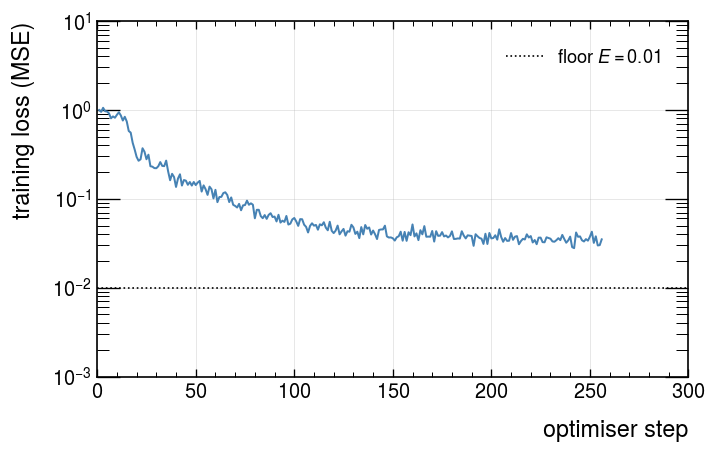

w=64, D=65,536: 100%|█████████▉| 255/256 [00:06<00:00, 37.28step/s]


N = 6,337 params    C = (6N-2dw)D = 2.22e+09 FLOPs    final val loss = 0.0341


In [2]:
val, steps, losses = train_cell_live(prob, width=64, n_data=65536, lr=0.005)
N = mlp_param_count(prob.input_dim, 64, 2)
C = compute(N, 65536, prob.input_dim, 64)
print(f"N = {N:,} params    C = (6N-2dw)D = {C:.2e} FLOPs    final val loss = {val:.4f}")

## The loss depends on $N$, $D$, and $\eta$

Train a spread of cells and watch the curves overlay (log step-axis): grow the **model** at fixed
$D$, then grow the **data** at fixed model (out to ~500k examples). Both a bigger model and more
data push the loss toward the floor. The learning rate is held at a single guess ($\eta=0.005$),
not optimal for every cell, which is the gap [notebook 01](01_tune_one_cell.ipynb) closes.

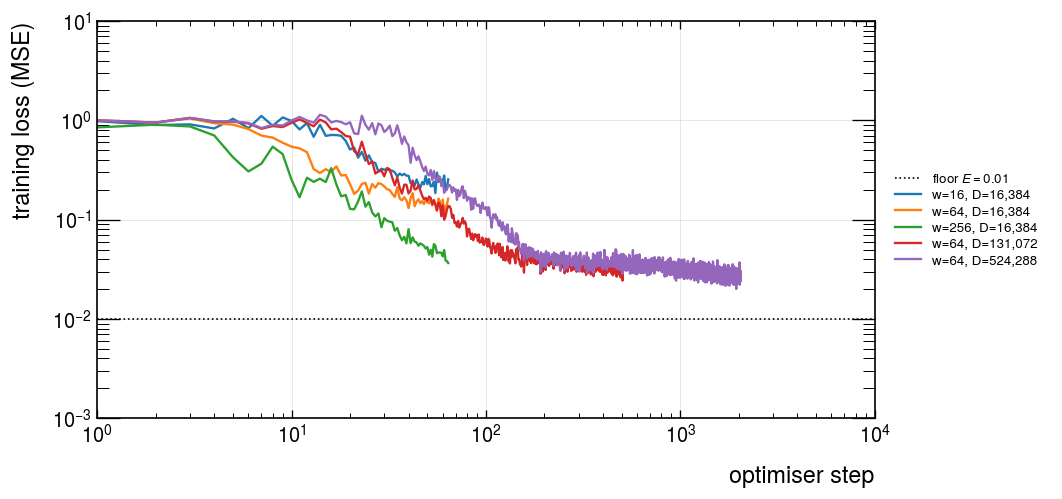

cells: 100%|██████████| 5/5 [00:03<00:00,  1.43cell/s]


,width,N,D,steps,C,val_loss
0,16,817,16384,64,6.353715e+07,0.225191
1,64,6337,16384,64,5.558436e+08,0.136498
2,256,74497,16384,64,7.054918e+09,0.043763
3,64,6337,131072,512,4.446749e+09,0.031275
4,64,6337,524288,2048,1.778699e+10,0.026598


In [3]:
grid = [(16, 16384), (64, 16384), (256, 16384),   # grow the model at fixed D
        (64, 131072), (64, 524288)]               # grow the data at fixed model
runs = train_cells_live(prob, grid, lr=0.005)
pd.DataFrame(runs)[["width", "N", "D", "steps", "C", "val_loss"]]

**Takeaway.** A cell maps $(N, D, \eta) \to$ loss. The compute axis is
$C=(6N-2dw)\,D$ (the $-2dw$ is a small first-layer correction to the usual $6ND$; we validate
it against a real FLOP counter in notebook 03).

But the loss above used a single fixed $\eta=0.005$. Is that the best choice for each cell? It
is not, and using a mis-tuned $\eta$ biases everything downstream. **[Notebook 01](01_tune_one_cell.ipynb)** finds the
optimal learning rate for one cell.

> **A note on the batch size.** Throughout these notebooks it is held fixed at $b=256$ for
> simplicity. In principle $b$ is a hyperparameter too, one that should be **tuned _and scaled_**
> (the optimal batch grows with the run, $b^\star\propto\sqrt T$) jointly with $\eta$. We keep it
> fixed and let the learning-rate law absorb the horizon dependence.